In [68]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [69]:
def sigmoid(x):
    return 1./(1.+np.exp(x))

class Perceptron:

    def __init__(self,lr=0.01,n_iter=50,random_state=1):
        self.lr = lr
        self.n_iter = n_iter
        self.random_state = random_state
    
    def fit(self,X,y):
        # assess X and y shapes
        assert(X.shape[0]==y.shape[0])
        self.errors = []
        # setup random state
        rgen = np.random.RandomState(seed=self.random_state)
        self.w_ = rgen.normal(loc=0.,scale=0.01,size=X.shape[1])
        self.b_ = 0.

        for i in range(self.n_iter):
            cost = 0.
            
            for xi,target in zip(X,y):
                
                z = np.dot(xi,self.w_)+self.b_
                pred = np.where(z>=0,1,0)
                #print(xi,target,z,pred)
                grad = (target-pred)
                self.w_ += self.lr*grad*xi
                self.b_ += self.lr*grad
                cost += grad**2
            #print(f"Iter:{i} Weight:{self.w_} Bias: {self.b_} Cost: {cost}")
            self.errors.append(cost)

    def net_input(self,X):
        return np.dot(X,self.w_)+self.b_
    
    def predict(self,X):
        z = np.dot(X,self.w_)+self.b_
        return np.where(z>=0,1,0)


In [70]:
perceptron = Perceptron(n_iter=10,lr=0.1)

In [71]:
df = pd.read_csv('data/iris.csv')

In [72]:
df.tail()

,sepal.length,sepal.width,petal.length,petal.width,variety
145,6.7,3.0,5.2,2.3,Virginica
146,6.3,2.5,5.0,1.9,Virginica
147,6.5,3.0,5.2,2.0,Virginica
148,6.2,3.4,5.4,2.3,Virginica
149,5.9,3.0,5.1,1.8,Virginica


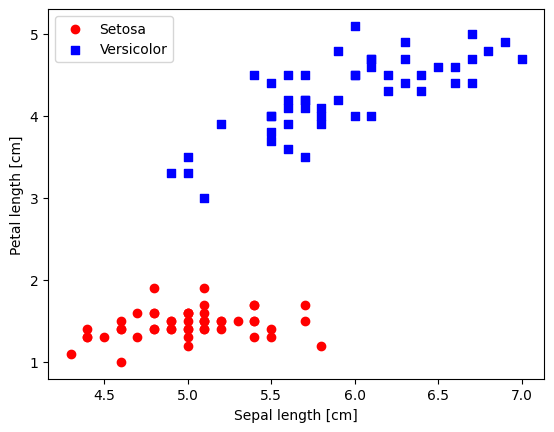

In [73]:
y = df.iloc[:,4].values
y = np.where(y=='Setosa',0,1)
X = df.iloc[:,[0,2]].values
plt.scatter(X[:50,0], X[:50,1],
            color='red', marker='o', label='Setosa')
plt.scatter(X[50:100,0],X[50:100,1],
            color='blue',marker='s',label='Versicolor')
plt.xlabel('Sepal length [cm]')
plt.ylabel('Petal length [cm]')
plt.legend(loc='upper left')
plt.show()

In [74]:
X.shape, y.shape

((150, 2), (150,))

In [75]:
perceptron.fit(X,y)

In [76]:
print(f"Errors:{perceptron.errors}")

Errors:[np.float64(2.0), np.float64(2.0), np.float64(3.0), np.float64(2.0), np.float64(1.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0)]


Text(0, 0.5, 'Sum-squared-error')

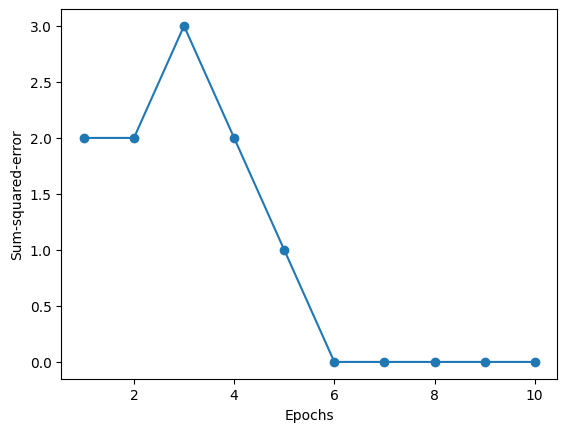

In [77]:
plt.plot(range(1,len(perceptron.errors)+1),perceptron.errors,marker='o')
plt.xlabel('Epochs')
plt.ylabel('Sum-squared-error')

In [78]:
# decision surface
from matplotlib.colors import ListedColormap
def plot_decision_regions(X,y,classifier,resolution=0.02):
    markers = ('o','s','^','v','<')
    colors = ('red','blue','lightgreen','gray','cyan')
    cmap = ListedColormap(colors[:len(np.unique(y))])

    x1_min, x1_max = X[:,0].min()-1, X[:,0].max()+1
    x2_min, x2_max = X[:,1].min()-1, X[:,1].max()+1

    xx1, xx2 = np.meshgrid(np.arange(x1_min,x1_max,resolution),
                           np.arange(x2_min,x2_max,resolution))
    
    lab = classifier.predict(np.array([xx1.ravel(),xx2.ravel()]).T)
    lab = lab.reshape(xx1.shape)
    plt.contourf(xx1,xx2,lab,alpha=0.3,cmap=cmap)
    plt.xlim(xx1.min(),xx1.max())
    plt.ylim(xx2.min(),xx2.max())

    for idx,cl in enumerate(np.unique(y)):
        plt.scatter(x=X[y==cl,0],
                    y=X[y==cl,1],
                    alpha=0.8, c=colors[idx],
                    marker=markers[idx],
                    label=f'Class {cl}',
                    edgecolor='black')

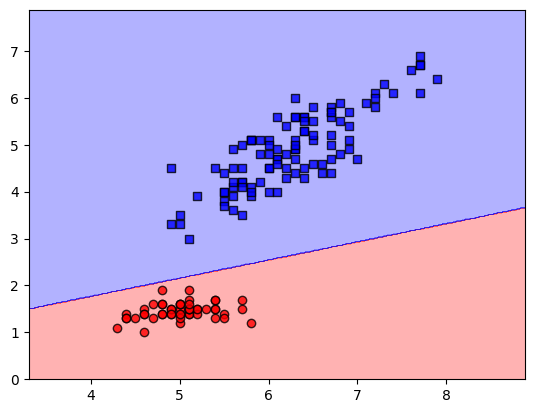

In [79]:
plot_decision_regions(X,y,classifier=perceptron)
plt.show()

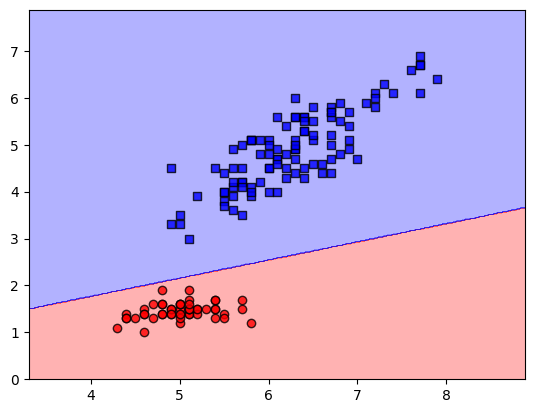

In [80]:
y_subset = y[(y==0) | (y==1)]
X_subset = X[(y==0) | (y==1)]
perceptron.fit(X_subset,y_subset)
plot_decision_regions(X_subset,y_subset,perceptron)